In [1]:
import numpy as np
from qibo import models, gates
import matplotlib.pyplot as plt

from tncdr.evolutors.tensor_network.tensor_network import TensorNetwork
from tncdr.evolutors.tensor_network.w_utils import (
    _compute_all_w_tensors,
    pauli_pauli_expansion,
    basis_pauli_expansion,
    X_pauli_expansion,
    theta_pauli_expansion
)

Ws = _compute_all_w_tensors()

def sample_random_pauli(n:int):
    possible_symbols = list('IXYZ')
    return ''.join([possible_symbols[np.random.randint(len(possible_symbols))] for _ in range(n)])

def pauli_tensors(pauli_string:str):
    for p in pauli_string:
        if 'IXYZ'.find(p) >= 0:
            yield Ws[p]

In [2]:
N=3
    
rotation_pauli = "YXZ"
observable = "XXZ"
theta =  2*np.pi*np.random.rand()
intial_state = '1' * N

print(f'Rotation generator: {rotation_pauli}')
print(f'H: {observable}')
print(f'rho_0: |{intial_state}X{intial_state}|')
print(f'theta: {theta}, {1-2*np.sin(theta/2)**2}, {2*np.sin(theta/2)*np.cos(theta/2)}')

# Build TensorNetwork
tn = TensorNetwork()

# Add initial state
for n, state in enumerate(intial_state):
    tn.add_tensor(f'T{n}', tensor=basis_pauli_expansion(state))

# Prepare initial state

# Add one rotation
# In general it is a unitary rotation generated by a Pauli string
# Generate the gate via qibo.gates.Unitary(matrix)
for n, w_tensor in enumerate(pauli_tensors(rotation_pauli)):
    tn.add_tensor(id=f'W{n}', tensor=w_tensor)
    tn.add_edge(f'T{n}', f'W{n}', 'v_link', (0,2))

tn.add_tensor(id='theta', tensor=theta_pauli_expansion(theta=theta))
tn.add_edge('theta', 'W0', 'h_link', (0,1))

for n in range(N-1):
    tn.add_edge(f'W{n}', f'W{n+1}', 'h_link', (0,1))

tn.add_tensor(id='X', tensor=X_pauli_expansion())
tn.add_edge(f'W{N-1}', 'X', 'h_link', (0,0))

# -----------------------

# Connect to the observable
for n, o in enumerate(observable):
    tn.add_tensor(f'O{n}', tensor=pauli_pauli_expansion(o))
    tn.add_edge(f'O{n}', f'W{n}', 'v_link', (0,3))

# -----------------------

# Contract the TensorNetwork
tn.contract('theta', 'W0', 'h_link', 'tmp')
for n in range(N-1):
    tn.contract(f'T{n}', 'tmp', 'v_link', 'tmp2')
    tn.contract(f'O{n}', 'tmp2', 'v_link', 'tmp3')
    tn.contract(f'tmp3', f'W{n+1}', 'h_link', 'tmp')

tn.contract(f'T{N-1}', 'tmp', 'v_link', 'tmp2')
tn.contract(f'O{N-1}', 'tmp2', 'v_link', 'tmp3')
tn.contract('tmp3', 'X', 'h_link', 'F')

# Output the result
print(tn.tensornet.nodes['F']['tensor'].item())

Rotation generator: YXZ
H: XXZ
rho_0: |111X111|
theta: 2.369017662046983, -0.7161157491584904, 0.6979815425977782
-0.6979815425977782


### Qibo version

In [3]:
import scipy
from qibo import Circuit, gates, hamiltonians
from qibo.symbols import X, Y, Z, I

In [4]:
gate_generator = Y(0) * X(1) * Z(2)
ham_matrix = hamiltonians.SymbolicHamiltonian(gate_generator).matrix

[Qibo 0.2.15|INFO|2025-02-11 17:32:52]: Using qibojit (numba) backend on /CPU:0
[Qibo 0.2.15|WARNING|2025-02-11 17:32:52]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


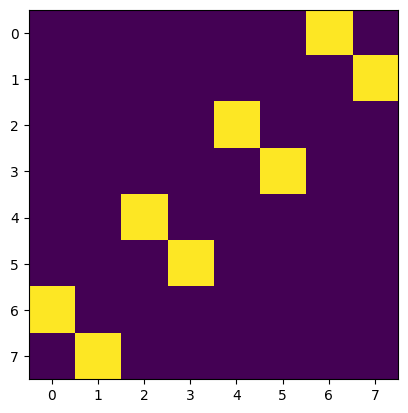

In [5]:
plt.imshow(np.abs(ham_matrix))

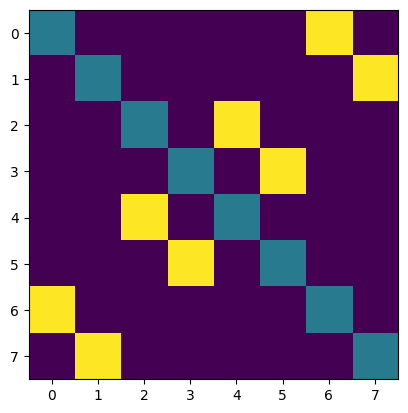

In [6]:
gate_matrix = scipy.linalg.expm(-1j * theta / 2 * ham_matrix)
plt.imshow(np.abs(gate_matrix))

In [7]:
my_gate = gates.Unitary(gate_matrix, *range(3))

In [8]:
c = Circuit(3)
[c.add(gates.X(q)) for q in range(3)]
c.add(my_gate)

In [9]:
c.draw()

0: ─X─U─
1: ─X─U─
2: ─X─U─


In [10]:
outcome = c()
print(outcome.state())
print("\n", outcome.probabilities())

[0.        +0.j 0.92631413+0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.37675207+0.j]

 [0.         0.85805787 0.         0.         0.         0.
 0.         0.14194213]


In [11]:
obs_form = X(0) * X(1) * Z(2)
obs_hamiltonian = hamiltonians.SymbolicHamiltonian(obs_form)

In [12]:
obs_hamiltonian.expectation(c().state())

-0.6979815425977781